In [32]:
# !pip install langchain_google_genai

In [33]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.messages import RemoveMessage

In [ ]:
model = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    api_key=""
)

In [35]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [36]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [37]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [38]:
graph = builder.compile(checkpointer=InMemorySaver())

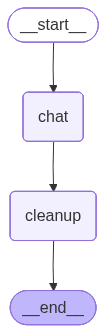

In [39]:
graph

In [40]:
config = {"configurable": {"thread_id": "t1"}}

In [41]:
# Run multiple turns
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Nitish"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain', additional_kwargs={}, response_metadata={}, id='f88b18f0-1e13-4779-a223-34d8469640b8'),
  AIMessage(content='LangChain is an open-source **framework** designed to help developers build applications powered by large language models (LLMs). It provides a structured way to connect LLMs with other sources of data and computation, enabling the creation of more complex, intelligent, and context-aware applications than simple prompt-response interactions.\n\nThink of LangChain as a **toolkit or a set of Lego bricks** specifically designed for building LLM-powered systems. Instead of just sending a single prompt to an LLM, LangChain allows you to orchestrate multiple steps, integrate external data, use various tools, and manage conversational memory.\n\n### Core Idea Behind LangChain\n\nThe core idea is to make it easier to:\n\n1.  **Connect LLMs to external data:** Give LLMs access to up-to-date information, personal data, or proprietary

In [42]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
